# Word Embeddings: Distributional Semantics

Word embeddings map each word to a dense vector of a few hundred dimensions, where
geometric relationships encode meaning. LSI gave us one vector per *document*;
word embeddings give one vector per *word*, so we can reason about language at the
lexical level. This notebook is the runnable companion to the book section
"Word Embeddings" and reproduces its worked example.

**Learning goals:**

- See the distributional hypothesis in action through nearest neighbors
- Visualize semantic clusters with a PCA projection
- Solve analogies through vector arithmetic and see where they fail
- Compare GloVe with fastText on out-of-vocabulary words
- Probe the polysemy limitation that motivates contextual embeddings

**Prerequisites:** ch05-01 (LSI as the first dense representation).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from shared.display import print_table, display_md

## Loading Pre-trained GloVe Vectors

We use GloVe vectors with 100 dimensions, trained on Wikipedia 2014 plus Gigaword
(5.6 billion tokens, 400,000 word vocabulary). These are the exact vectors behind
the book's Example, so the printed numbers below match the text.

<div style="border-left: 4px solid #0284C7; background: rgba(2, 132, 199, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#0284C7; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">One-time download</strong><br>
<code>gensim</code> downloads the model on first use (about 128 MB) and caches it under <code>~/gensim-data/</code>. Later runs load it from the cache in a few seconds. No manual download step is needed; the call below handles it.
</div>

In [2]:
import gensim.downloader as api

# 100-dimensional GloVe vectors (matches the book Example)
wv = api.load("glove-wiki-gigaword-100")

display_md(
    f"**GloVe vectors loaded**\n\n"
    f"| Property | Value |\n"
    f"|----------|-------|\n"
    f"| Vocabulary size | {len(wv):,} words |\n"
    f"| Dimensions | {wv.vector_size} |\n"
    f"| Vector shape (per word) | {wv['king'].shape} |"
)

**GloVe vectors loaded**

| Property | Value |
|----------|-------|
| Vocabulary size | 400,000 words |
| Dimensions | 100 |
| Vector shape (per word) | (100,) |

A note on the similarity measure: `gensim` normalizes vectors to unit length before
comparing them, so `most_similar` and `similarity` report cosine similarity. For
static word vectors cosine is the standard choice, because a vector's length
correlates with word frequency rather than meaning; cosine factors magnitude out and
compares direction only.

## The Distributional Hypothesis

*"You shall know a word by the company it keeps."* (Firth, 1957)

Words that appear in similar contexts receive similar vectors. The book's Example
asks for the three closest words to "cat"; we reproduce it here.

In [3]:
# The book Example: three nearest neighbors of "cat"
display_md("**Nearest neighbors of 'cat' (book Example):**")
print_table(
    [[i + 1, word, f"{score:.2f}"] for i, (word, score) in enumerate(wv.most_similar("cat", topn=3))],
    headers=["Rank", "Word", "Cosine"],
)

**Nearest neighbors of 'cat' (book Example):**

|   Rank | Word   |   Cosine |
|-------:|:-------|---------:|
|      1 | dog    |     0.88 |
|      2 | rabbit |     0.74 |
|      3 | cats   |     0.73 |

The result is `dog` (0.88), `rabbit` (0.74), `cats` (0.73): the neighborhood of "cat"
is full of other animals and its own plural, exactly as the distributional hypothesis
predicts. Let us look at a few more words to see how each one sits in a meaningful
neighborhood.

In [4]:
# Compare the neighborhoods of words from different domains
probe_words = ["king", "computer", "river", "doctor"]

rows = []
for word in probe_words:
    neighbors = ", ".join(w for w, _ in wv.most_similar(word, topn=5))
    rows.append([word, neighbors])

display_md("**Top-5 neighbors across different domains:**")
print_table(rows, headers=["Word", "Nearest Neighbors"])

**Top-5 neighbors across different domains:**

| Word     | Nearest Neighbors                             |
|:---------|:----------------------------------------------|
| king     | prince, queen, son, brother, monarch          |
| computer | computers, software, technology, pc, hardware |
| river    | rivers, creek, lake, valley, danube           |
| doctor   | physician, nurse, dr., doctors, patient       |

Each word lands among semantically related words: "king" among royalty, "computer"
among hardware and software, "river" among bodies of water, "doctor" among medical
roles. The geometry encodes meaning without anyone labeling it.

## Semantic Clusters: A PCA Projection

Words from the same semantic field cluster together. We take four categories and
project their 100-dimensional vectors down to two dimensions with PCA, reproducing
the clustering figure from the book.

In [5]:
groups = {
    "Animals": ["cat", "dog", "rabbit", "horse", "lion", "elephant"],
    "Meals":   ["breakfast", "lunch", "dinner", "supper", "meal", "snack"],
    "Cities":  ["paris", "berlin", "london", "tokyo", "madrid", "rome"],
    "People":  ["man", "woman", "king", "queen", "boy", "girl"],
}

words, vectors, labels = [], [], []
for group, members in groups.items():
    for word in members:
        words.append(word)
        vectors.append(wv[word])
        labels.append(group)

vectors = np.array(vectors)
coords = PCA(n_components=2).fit_transform(vectors)

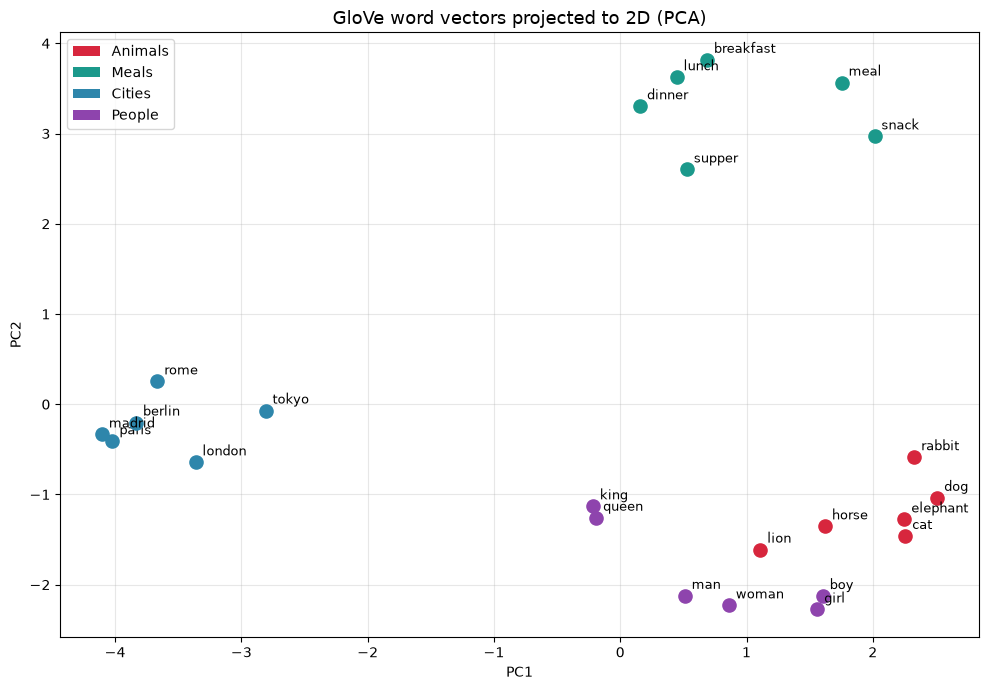

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = {"Animals": "#D7263D", "Meals": "#1B998B",
           "Cities": "#2E86AB", "People": "#8E44AD"}

for (x, y), word, label in zip(coords, words, labels):
    ax.scatter(x, y, c=palette[label], s=90, zorder=3)
    ax.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=g) for g, c in palette.items()],
          loc="best", fontsize=10)
ax.set_title("GloVe word vectors projected to 2D (PCA)", fontsize=13)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The four categories occupy distinct regions even after compressing 100 dimensions to
2. No category labels were used during training: the structure emerges purely from
co-occurrence statistics in the text.

## Vector Arithmetic and Analogies

The most striking emergent property is that semantic relationships become **directions**
in vector space. Adding and subtracting word vectors solves analogies. The book's
Example is the Paris analogy:

$$\vec{\text{paris}} - \vec{\text{france}} + \vec{\text{germany}} \approx \vec{\text{berlin}}$$

In [7]:
# The book Example: Paris - France + Germany = ?
berlin = wv.most_similar(positive=["paris", "germany"], negative=["france"], topn=1)
queen = wv.most_similar(positive=["king", "woman"], negative=["man"], topn=1)

display_md(
    f"**paris - france + germany =** `{berlin[0][0]}` ({berlin[0][1]:.2f})\n\n"
    f"**king - man + woman =** `{queen[0][0]}` ({queen[0][1]:.2f})"
)

**paris - france + germany =** `berlin` (0.88)

**king - man + woman =** `queen` (0.77)

Both match the book: the capital analogy returns `berlin` (0.88) and the gender
analogy returns `queen` (0.77). We read the relation as "a : b :: c : ?", which the
model answers with `most_similar(positive=[b, c], negative=[a])`.

In [8]:
# A batch of analogies: a : b :: c : ?
analogies = [
    ("france", "paris", "germany", "berlin"),   # country : capital
    ("man", "king", "woman", "queen"),          # gender
    ("france", "paris", "japan", "tokyo"),      # country : capital
    ("good", "better", "bad", "worse"),         # comparative
    ("walk", "walked", "run", "ran"),           # past tense
]

rows = []
for a, b, c, expected in analogies:
    word, score = wv.most_similar(positive=[b, c], negative=[a], topn=1)[0]
    rows.append([f"{a} : {b} :: {c} : ?", expected, word, f"{score:.2f}",
                 "yes" if word == expected else "no"])

display_md("**Analogy test** (a : b :: c : ?):")
print_table(rows, headers=["Analogy", "Expected", "Predicted", "Score", "Match"])

**Analogy test** (a : b :: c : ?):

| Analogy                       | Expected   | Predicted   |   Score | Match   |
|:------------------------------|:-----------|:------------|--------:|:--------|
| france : paris :: germany : ? | berlin     | berlin      |    0.88 | yes     |
| man : king :: woman : ?       | queen      | queen       |    0.77 | yes     |
| france : paris :: japan : ?   | tokyo      | tokyo       |    0.9  | yes     |
| good : better :: bad : ?      | worse      | worse       |    0.84 | yes     |
| walk : walked :: run : ?      | ran        | went        |    0.71 | no      |

Four of the five land on the expected word. The past-tense case misses: the model
returns `went` instead of `ran`, because irregular verb forms are statistically rarer
and less consistent than the regular geometric patterns the model captures well.

## When Analogies Fail

Vector arithmetic encodes statistical co-occurrence, not logical truth. Some analogies
expose biases in the training data, and some simply have no clean linear structure.

In [9]:
# a : b :: c : ? , showing the top three candidates
failures = [
    ("man", "doctor", "woman"),   # occupational gender association
    ("good", "best", "bad"),      # irregular superlative
]

rows = []
for a, b, c in failures:
    top3 = ", ".join(f"{w} ({s:.2f})" for w, s in wv.most_similar(positive=[b, c], negative=[a], topn=3))
    rows.append([f"{a} : {b} :: {c} : ?", top3])

display_md("**Problematic analogies:**")
print_table(rows, headers=["Analogy", "Top-3 Predictions"])

**Problematic analogies:**

| Analogy                   | Top-3 Predictions                              |
|:--------------------------|:-----------------------------------------------|
| man : doctor :: woman : ? | nurse (0.77), physician (0.72), doctors (0.68) |
| good : best :: bad : ?    | worst (0.70), movie (0.67), big (0.67)         |

The first row returns `nurse` as the top answer for "man : doctor :: woman : ?": the
training corpus associates these occupations with gender, and the vectors inherit that
bias. The second row shows noise rather than the clean "worst" we might expect, because
irregular superlatives do not sit on a consistent direction. The lesson: embeddings
mirror their data, including its stereotypes.

## GloVe versus fastText on Unknown Words

GloVe assigns one vector per word in its fixed vocabulary. A word that never appeared
during training is simply unknown: there is no vector to return. Modern terms are a
common case.

In [10]:
# Words coined or popularized after the GloVe training corpus
new_words = ["cryptocurrency", "chatbot", "blockchain", "emojis", "selfie"]

rows = [[w, "in vocabulary" if w in wv else "unknown (no vector)"] for w in new_words]
display_md("**Are these words in GloVe-100?**")
print_table(rows, headers=["Word", "GloVe status"])

**Are these words in GloVe-100?**

| Word           | GloVe status        |
|:---------------|:--------------------|
| cryptocurrency | unknown (no vector) |
| chatbot        | unknown (no vector) |
| blockchain     | unknown (no vector) |
| emojis         | unknown (no vector) |
| selfie         | unknown (no vector) |

All five are unknown to GloVe: asking for their vector raises a `KeyError`. fastText
solves this by building a word vector from its character n-grams, so any string gets a
vector composed from its parts. To see this concretely we train a small fastText model
on a classic English corpus and then query it with these modern, out-of-vocabulary
words.

<div style="border-left: 4px solid #0284C7; background: rgba(2, 132, 199, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#0284C7; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">One-time download</strong><br>
The training corpus is the Brown corpus (about 1 million words), fetched through <code>nltk</code> on first run (a few MB). Training the small model takes a few seconds.
</div>

In [11]:
import nltk
from gensim.models import FastText

nltk.download("brown", quiet=True)
from nltk.corpus import brown

# Sentences of lowercase alphabetic tokens
sentences = [[w.lower() for w in sent if w.isalpha()] for sent in brown.sents()]

ft = FastText(
    sentences=sentences, vector_size=100, window=5, min_count=3,
    min_n=3, max_n=6, epochs=8, sg=1, seed=42, workers=4,
)

display_md(
    f"**fastText trained on the Brown corpus**\n\n"
    f"| Property | Value |\n"
    f"|----------|-------|\n"
    f"| Sentences | {len(sentences):,} |\n"
    f"| Vocabulary | {len(ft.wv):,} full words |\n"
    f"| Dimensions | {ft.wv.vector_size} |"
)

**fastText trained on the Brown corpus**

| Property | Value |
|----------|-------|
| Sentences | 57,340 |
| Vocabulary | 18,954 full words |
| Dimensions | 100 |

In [12]:
# The same modern words: fastText composes a vector from character n-grams
rows = []
for word in ["cryptocurrency", "chatbot", "blockchain", "emojis", "selfie"]:
    in_vocab = word in ft.wv.key_to_index
    neighbors = ", ".join(w for w, _ in ft.wv.most_similar(word, topn=4))
    rows.append([word, "yes" if in_vocab else "no (composed)", neighbors])

display_md("**fastText neighbors for words it never saw during training:**")
print_table(rows, headers=["Word", "Seen in corpus?", "fastText neighbors (from subwords)"])

**fastText neighbors for words it never saw during training:**

| Word           | Seen in corpus?   | fastText neighbors (from subwords)      |
|:---------------|:------------------|:----------------------------------------|
| cryptocurrency | no (composed)     | currency, efficacy, redundancy, potency |
| chatbot        | no (composed)     | chat, chariot, chatham, chavez          |
| blockchain     | no (composed)     | bloc, blockade, block, floc             |
| emojis         | no (composed)     | emma, xydis, emory, nicodemus           |
| selfie         | no (composed)     | selfish, oneself, cliche, kayabashi     |

None of these words appear in a 1960s corpus, yet fastText still returns a vector and
sensible neighbors by reusing character n-grams it has seen: "cryptocurrency" lands
near "currency", "chatbot" near "chat". The neighbors are only as good as the subwords
the small corpus contains, but the key point holds: fastText never fails on an unknown
word, where GloVe has no entry at all. This same mechanism gives related vectors to
morphological variants such as "happy", "happiness", and "unhappiness" without any
explicit stemming.

## The Polysemy Problem

A fundamental limit of static embeddings: each word gets exactly **one** vector,
regardless of context. Take "apple". The token names both a technology company and a
fruit, but GloVe has only a single point to hold both senses.

In [13]:
# The ten nearest neighbors of "apple"
display_md("**Nearest neighbors of 'apple':**")
print_table(
    [[i + 1, w, f"{s:.2f}"] for i, (w, s) in enumerate(wv.most_similar("apple", topn=10))],
    headers=["Rank", "Word", "Cosine"],
)

**Nearest neighbors of 'apple':**

|   Rank | Word      |   Cosine |
|-------:|:----------|---------:|
|      1 | microsoft |     0.74 |
|      2 | ibm       |     0.68 |
|      3 | intel     |     0.68 |
|      4 | software  |     0.68 |
|      5 | dell      |     0.67 |
|      6 | pc        |     0.67 |
|      7 | macintosh |     0.66 |
|      8 | iphone    |     0.66 |
|      9 | ipod      |     0.65 |
|     10 | hewlett   |     0.65 |

Every neighbor is a technology company or product (microsoft, ibm, intel, dell,
macintosh, iphone): the fruit sense does not appear at all. Apple the company is far more
frequent in the training text than apple the food, so the frequent sense captures almost
the whole vector and the minority sense becomes effectively invisible.

This is not special to "apple". Each word below carries several unrelated senses, yet
gets one vector, and in every case the most frequent sense dominates.

In [14]:
polysemous = ["bank", "apple", "mouse", "python"]

rows = []
for word in polysemous:
    neighbors = ", ".join(w for w, _ in wv.most_similar(word, topn=5))
    rows.append([word, neighbors])

display_md("**One vector per word: which sense dominates?**")
print_table(rows, headers=["Word", "Nearest Neighbors (dominant sense)"])

**One vector per word: which sense dominates?**

| Word   | Nearest Neighbors (dominant sense)            |
|:-------|:----------------------------------------------|
| bank   | banks, banking, credit, investment, financial |
| apple  | microsoft, ibm, intel, software, dell         |
| mouse  | cat, rabbit, monkey, mice, rat                |
| python | monty, php, perl, cleese, flipper             |

The neighborhoods reveal the dominant training sense: "bank" leans financial
(banks, banking, credit), "apple" leans company, "mouse" leans animal
(cat, rabbit, mice), and "python" mixes the comedy troupe with the programming language
(monty, perl, php). The river bank, the fruit, and the computer mouse all share the one
vector, so their minority senses are effectively invisible.

### Homonyms versus Synonyms

It helps to separate two situations that static embeddings treat very differently:

- **Homonyms**: one token, several unrelated meanings (Apple the company versus apple
  the fruit). This is the hard case: all senses collapse into one point, dominated by
  the most frequent one.
- **Synonyms**: different tokens, the same meaning (big and large). This is the easy
  case: words used in the same contexts land near each other in space.

The synonym case is the good news, and we can check it directly.

In [15]:
# Synonym pairs: different spellings, same meaning
synonym_pairs = [("big", "large"), ("car", "automobile"), ("happy", "glad"), ("buy", "purchase")]

rows = [[a, b, f"{wv.similarity(a, b):.2f}"] for a, b in synonym_pairs]
display_md("**Synonym pairs: cosine similarity**")
print_table(rows, headers=["Word A", "Word B", "Cosine"])

**Synonym pairs: cosine similarity**

| Word A   | Word B     |   Cosine |
|:---------|:-----------|---------:|
| big      | large      |     0.71 |
| car      | automobile |     0.68 |
| happy    | glad       |     0.78 |
| buy      | purchase   |     0.83 |

Each pair scores high (around 0.68 to 0.83): different spellings, nearly the same
direction in space. So synonyms map well, while homonyms collapse. The difference is
context: deciding which sense of "apple" is meant needs the surrounding words, which a
single static vector cannot carry.

<div style="border-left: 4px solid #C8102E; background: rgba(200, 16, 46, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#C8102E; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Synonyms map well, homonyms collapse</strong><br>
Static embeddings place synonyms (different words, one meaning) close together, which is exactly what retrieval wants. But a homonym like "apple" or "bank" collapses its unrelated senses into one fixed vector, dominated by the most frequent sense. Resolving a homonym needs the surrounding context, which a static vector cannot see. This is the central motivation for contextual, transformer-based embeddings in the next section.
</div>

## From Words to Sentences: Why Pooling Is Not Enough

Retrieval compares queries and documents, not single words. The obvious way to turn a
sequence of word vectors into one vector is **average pooling**: take the element-wise
mean of the token vectors. It is a reasonable first step, but it loses important
information.

In [16]:
def pooled_vector(sentence):
    """Average-pool the GloVe vectors of the words in a sentence."""
    tokens = [t for t in sentence.lower().split() if t in wv]
    return np.mean([wv[t] for t in tokens], axis=0)

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

pairs = [
    ("the cat sat on the mat", "a kitten rested on the rug"),   # same meaning
    ("the cat sat on the mat", "the stock market crashed today"), # unrelated
    ("dog bites man", "man bites dog"),                           # word order
]

rows = [[s1, s2, f"{cosine(pooled_vector(s1), pooled_vector(s2)):.3f}"] for s1, s2 in pairs]
display_md("**Average-pooled sentence similarity:**")
print_table(rows, headers=["Sentence A", "Sentence B", "Cosine"])

**Average-pooled sentence similarity:**

| Sentence A             | Sentence B                     |   Cosine |
|:-----------------------|:-------------------------------|---------:|
| the cat sat on the mat | a kitten rested on the rug     |    0.921 |
| the cat sat on the mat | the stock market crashed today |    0.771 |
| dog bites man          | man bites dog                  |    1     |

Two problems show up at once. The unrelated pair still scores high (around 0.77):
averaging many vectors, including stop words, pulls every sentence toward a bland
centroid, so distinct texts look similar. And "dog bites man" versus "man bites dog"
scores a perfect 1.0: average pooling ignores word order entirely, because both
sentences contain the same tokens. Pooling throws away syntax and long-range structure.

These shortcomings point to a model that produces a single vector for a whole sequence
while weighing how all tokens relate to each other. That is exactly what transformer
encoders provide, and what the next notebook explores.

## Summary

- Word embeddings place each word at a point in a dense space; nearest neighbors and
  clusters show that distance encodes meaning.
- Semantic relationships become directions, so analogies can be solved with vector
  arithmetic. The patterns are statistical, so biased or irregular relations fail.
- GloVe cannot represent words outside its fixed vocabulary; fastText composes a vector
  from character n-grams and never fails on an unknown word.
- Each static word has exactly one vector, so polysemy is unresolved and simple pooling
  cannot build faithful sentence vectors. Both limits motivate contextual embeddings.

## Try It Yourself

In [17]:
# 1. Odd one out: the word least like the others in a group
display_md(
    f"**Odd one out** of [breakfast, lunch, dinner, computer]: "
    f"**{wv.doesnt_match(['breakfast', 'lunch', 'dinner', 'computer'])}**"
)

**Odd one out** of [breakfast, lunch, dinner, computer]: **computer**

In [18]:
# 2. How similar are two words? 0 means unrelated, 1 means identical direction
pairs = [("cat", "dog"), ("cat", "car"), ("happy", "joyful"), ("hot", "cold")]
rows = [[a, b, f"{wv.similarity(a, b):.2f}"] for a, b in pairs]
display_md("**Pairwise cosine similarity:**")
print_table(rows, headers=["Word A", "Word B", "Cosine"])

**Pairwise cosine similarity:**

| Word A   | Word B   |   Cosine |
|:---------|:---------|---------:|
| cat      | dog      |     0.88 |
| cat      | car      |     0.31 |
| happy    | joyful   |     0.53 |
| hot      | cold     |     0.73 |

In [19]:
# 3. Build your own analogy: change the three words and re-run
a, b, c = "italy", "rome", "spain"   # a : b :: c : ?
word, score = wv.most_similar(positive=[b, c], negative=[a], topn=1)[0]
display_md(f"**{a} : {b} :: {c} : ?** returns `{word}` ({score:.2f})")

**italy : rome :: spain : ?** returns `madrid` (0.70)